<a href="https://colab.research.google.com/github/ravali217/Perceptron-Deep-learning/blob/main/tenserflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#diabetes risk prediction(usiing tensorflow frame work)
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [ ]:
x=np.array([
    [120,25],[85,30],[150,35],[95,22]
])
x=x/200
y=np.array(([1,0,1,0]))
print("input shape:",x.shape)
print("output shape:",y.shape)


input shape: (4, 2)
output shape: (4,)


In [ ]:
# build neural network model
model=Sequential([
    Dense(3,input_shape=(2,),activation='sigmoid'),
    Dense(1,activation='sigmoid')

])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#train the model
model.fit(x,y,epochs=500,verbose=0)

In [ ]:
#make predictions
predictions=model.predict(x)
print("predictions:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
predictions:
[[0.501066  ]
 [0.5041667 ]
 [0.50065076]
 [0.5021914 ]]


In [ ]:
#goal:
# predict which flower species an iris belongs to.
# classes:
#   1. setosa,2. versicolor,3.virginica
# inputlayer (4 neurons)
# hidden layer(10 neurons,relu)
# hidden layer(5 neurons,relu)
# output layer(3 neuronos,softmax)



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import argmax
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score




In [ ]:
# load the iris dataset
iris=load_iris()
x=iris.data
y=iris.target
target_names=iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
#plot the dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#standardize the features
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
#define the model architecture
model=Sequential()
model.add(Dense(10,activation='relu',input_shape=(x_train.shape[1],)))
model.add(Dense(5,activation='relu'))
model.add(Dense(3,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123 (492.00 B)

 Trainable params: 123 (492.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=50,batch_size=8,validation_split=0.1,verbose=1)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.9428 - loss: 0.2462 - val_accuracy: 1.0000 - val_loss: 0.2921
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9524 - loss: 0.2107 - val_accuracy: 1.0000 - val_loss: 0.2814
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9297 - loss: 0.2373 - val_accuracy: 1.0000 - val_loss: 0.2734
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9693 - loss: 0.2183 - val_accuracy: 1.0000 - val_loss: 0.2651
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9524 - loss: 0.2174 - val_accuracy: 1.0000 - val_loss: 0.2565
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9813 - loss: 0.1719 - val_accuracy: 1.0000 - val_loss: 0.2484
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9841 - loss: 0.1828 - val_accuracy: 1.0000 - val_loss: 0.2471
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9399 - loss: 0.1964 - val_accuracy: 1.0000 - 

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f"Test Accuracy:",test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step - accuracy: 0.9667 - loss: 0.0764
Test Accuracy: 0.9666666388511658


In [ ]:
y_pred_proba=model.predict(x_test)
y_pred=argmax(y_pred_proba,axis=1)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Accuracy: 0.9666666666666667


car price prediction


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/CarPrice_dataset.csv'
df=pd.read_csv(path)
df.head()

Mounted at /content/drive


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.isna().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer




# Optional: create brand column from CarName
df["brand"] = df["CarName"].apply(lambda x: x.split()[0])

# Drop unnecessary columns
df = df.drop(["car_ID", "CarName"], axis=1)

# Separate input features and target
X = df.drop("price", axis=1)
y = df["price"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

# Preprocessing:
# OneHotEncoding for categorical columns
# StandardScaler for numerical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit and transform training data
X_train = preprocessor.fit_transform(X_train)

# Transform test data
X_test = preprocessor.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Categorical columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']
Numerical columns: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
X_train shape: (164, 68)
X_test shape: (41, 68)
y_train shape: (164,)
y_test shape: (41,)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [7, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build Feed Forward Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)   # Output layer for price prediction
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Display model summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model on test data
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

# Predict car prices
y_pred = model.predict(X_test)

print("Sample Predictions:")
print(y_pred[:5])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 648ms/step - loss: 220983520.0000 - mae: 12833.0635 - val_loss: 317937952.0000 - val_mae: 15082.8242
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 220597872.0000 - mae: 12968.2256 - val_loss: 317926048.0000 - val_mae: 15082.4902
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 195033632.0000 - mae: 12294.0859 - val_loss: 317913504.0000 - val_mae: 15082.1357
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 223896512.0000 - mae: 13164.5840 - val_loss: 317899360.0000 - val_mae: 15081.7305
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 202770944.0000 - mae: 12503.7520 - val_loss: 317882816.0000 - val_mae: 15081.2617
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 223120416.0000 - mae: 12923.1689 - val_loss: 317861856.0000 - val_mae: 15080.6816
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 230360448.0000 - mae: 13034.2471 - val_loss: 317835968.0000 - val_mae: 15079.9717
Epoch 8/100
5/5 ━━━

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 93072392.0000 - mae: 7958.6875 - val_loss: 130757744.0000 - val_mae: 9166.1924
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 82881936.0000 - mae: 7529.3901 - val_loss: 127082296.0000 - val_mae: 9013.2275
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 84831888.0000 - mae: 7594.8296 - val_loss: 123080000.0000 - val_mae: 8848.3926
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 78249480.0000 - mae: 7171.6094 - val_loss: 119441688.0000 - val_mae: 8693.2256
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 73547384.0000 - mae: 7024.7896 - val_loss: 115926496.0000 - val_mae: 8539.2188
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 73511192.0000 - mae: 6901.9863 - val_loss: 112553504.0000 - val_mae: 8386.4268
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 63120344.0000 - mae: 6558.2910 - val_loss: 109244544.0000 - val_mae: 8233.5645
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

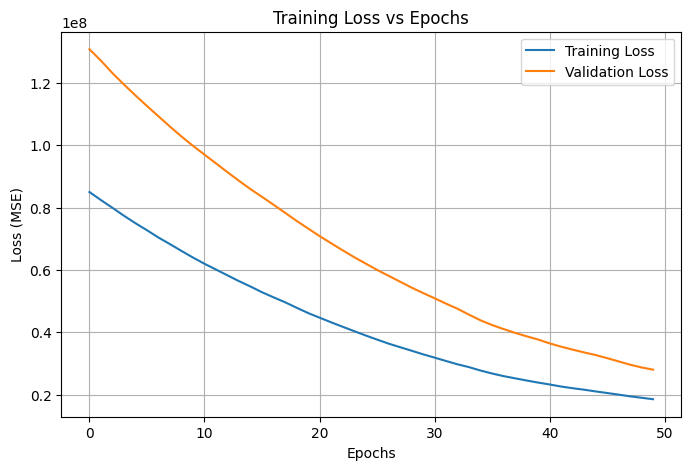

In [ ]:
import matplotlib.pyplot as plt

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Visualize Training Loss vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on test set
y_pred = model.predict(X_test)

# Convert predictions into 1D array
y_pred = y_pred.flatten()

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Model Evaluation Results
MAE  : 3665.8830985137197
MSE  : 27243993.746420998
RMSE : 5219.577927995807
R² Score : 0.654894779327851


In [ ]:
print("\nInterpretation:")
if r2 > 0.8:
    print("The model is performing well and explains most of the variance in car prices.")
elif r2 > 0.6:
    print("The model is reasonably accurate, but there is still room for improvement.")
else:
    print("The model accuracy is low, and further tuning or feature engineering is needed.")



Interpretation:
The model is reasonably accurate, but there is still room for improvement.


CAR PRICE DATASET (by using tensorflow)


In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/CarPrice_dataset.csv'
df=pd.read_csv(path)
print(df.head())

Mounted at /content/drive
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio hors

In [3]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [5]:
from pandas.core.arrays import categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
x=df.drop(columns='price')
y=df['price']
categorical_cols=x.select_dtypes(include=['object']).columns.tolist()
numerical_cols=x.select_dtypes(include=['int64','float64']).columns.tolist()
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('car',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ])
x_processed=preprocessor.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_processed,y,test_size=0.2,random_state=42)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential([
    Dense(512,activation='relu',input_shape=(x_train.shape[1],)),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1)
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 277,505 (1.06 MB)

 Trainable params: 277,505 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam',loss='mean_absolute_error',
              metrics=['mean_absolute_error','mean_squared_error'])

In [11]:
historical=model.fit(x_train,y_train,epochs=50,validation_split=0.2,verbose=1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 564.8735 - mean_absolute_error: 564.8735 - mean_squared_error: 721633.2500 - val_loss: 2117.3059 - val_mean_absolute_error: 2117.3059 - val_mean_squared_error: 10158314.0000
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 552.6275 - mean_absolute_error: 552.6275 - mean_squared_error: 694782.1875 - val_loss: 2006.0225 - val_mean_absolute_error: 2006.0225 - val_mean_squared_error: 8323599.5000
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 493.6516 - mean_absolute_error: 493.6516 - mean_squared_error: 587012.5000 - val_loss: 2054.0820 - val_mean_absolute_error: 2054.0820 - val_mean_squared_error: 9097392.0000
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 447.6068 - mean_absolute_error: 447.6068 - mean_squared_error: 633178.6250 - val_loss: 1991.1439 - val_mean_absolute_error: 1991.1439 - val_mean_squared_error: 7912516.0000
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 424.4911 - mean_absolu

In [12]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"mean absolute eroor: {mae}")
print(f"mean squared error: {mse}")
print(f"r2 score: {r2}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
mean absolute eroor: 1927.8711411966462
mean squared error: 9536446.118224543
r2 score: 0.8791998936466398
